# Static yaw misalignment
## Physics-informed long-term vane calibration

**Winner → robustness → domain shift → frozen predictions.**

This notebook consolidates verified existing work. It recomputes the final calibration, strict LOTO scores and block-bootstrap summaries from a small derived B0 cache. Historical models are not retrained. No CSV, JSON or figure folders are written.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
%matplotlib inline

# Works in the original repository and in the standalone release folder.
HERE = Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents]
            if (p / "src/make_final_submission_vane_level.py").exists()
            or (p / "github_release/src/make_final_submission_vane_level.py").exists())
RELEASE = ROOT if (ROOT / "src").exists() else ROOT / "github_release"
sys.path.insert(0, str(RELEASE / "src"))
from make_final_submission_vane_level import (
    TRAIN, TARGETS, load_daily, turbine_summary, validate_loto, predict_targets,
    bootstrap_loto, bootstrap_targets, run_frozen_scada,
)

# Optional: requires separately obtained private cleaned SCADA; default uses cache.
RECOMPUTE_SCADA = False
ZIP_PATH = ROOT / "turbines_data.zip"
daily = load_daily(RELEASE / "data/vane_daily.csv")
if RECOMPUTE_SCADA:
    rebuilt = run_frozen_scada(ZIP_PATH)
    for turbine in TRAIN + TARGETS:
        np.testing.assert_allclose(
            rebuilt.loc[rebuilt.turbine_id.eq(turbine), "theta_hat_argmax"].median(),
            daily.loc[daily.turbine_id.eq(turbine), "theta_hat_argmax"].median(), atol=1e-8)
    daily = rebuilt.assign(date=pd.to_datetime(rebuilt.date))

summary = turbine_summary(daily)
loto = validate_loto(daily)
points = predict_targets(daily)
C_FINAL = summary.C_i.mean()
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.16})
COLORS = ["#16857d", "#dc7633", "#526ab0"]
print(f"Derived cache: {len(daily):,} daily records; no raw SCADA columns. No files will be written.")

Derived cache: 3,615 daily records; no raw SCADA columns. No files will be written.


## 1. Problem and physical framing

$$\gamma=\operatorname{wrap}(WindDir-NacDir)\in[-180^\circ,180^\circ).$$

Gamma is measured in the turbine's vane/controller reference frame; it is **not** the true yaw label. Persistent reference or aerodynamic bias can remain. Qualitatively, yaw attenuation follows $P(\theta)\sim P_0\cos^p(\theta)$, but this final model does not fit the exponent or invert that relation.

Static yaw is treated as a persistent turbine-level state. The winning method estimates the long-term location of peak relative power, then calibrates its reference and sign.

## 2. Data and validation

Three labelled development turbines: **PPP_WTG12/13/14**. **PPP_WTG17** is the public validation target; **SSS_WTG06** is the final target. Both target labels are withheld. Context turbines were used only for controlled diagnostics after model development.

Each outer LOTO fold estimates calibration using the other two labelled turbines. No random row split is used. The held-out turbine contributes its unlabeled full-history vane estimate, making this an **offline/transductive** evaluation rather than future-time forecasting.

Only three labelled turbines were available. The formula was discovered through repeated inspection of those turbines; strict fold calculations do not make this an independent external benchmark.

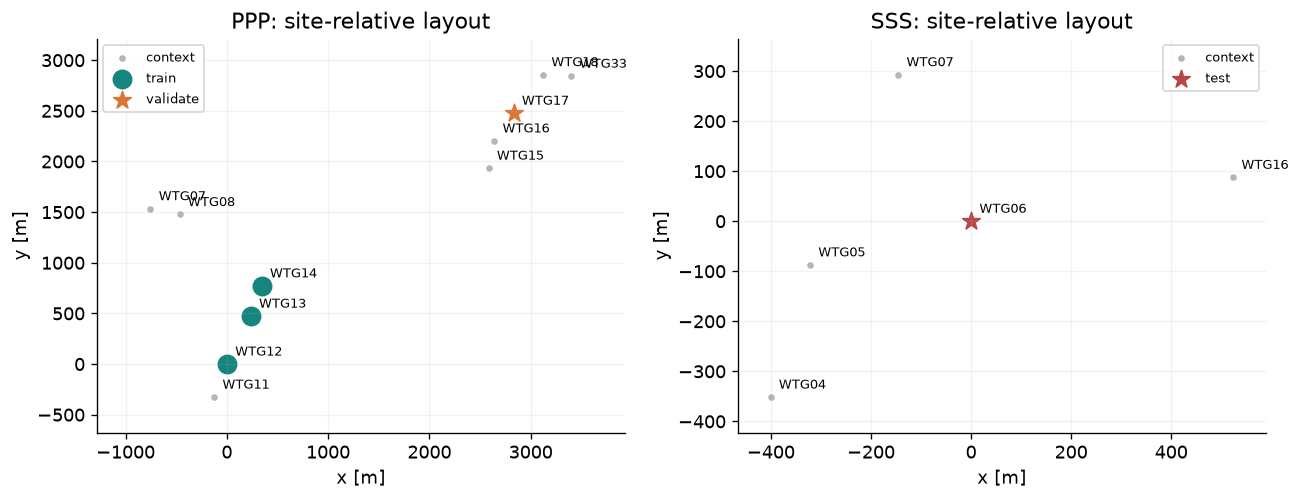

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
role_style = {"train": ("#16857d", "o"), "validate": ("#dc7633", "*"),
              "test": ("#b74747", "*"), "context": ("#b0b6be", ".")}
for ax, site in zip(axes, ["PPP", "SSS"]):
    loc = pd.read_csv(RELEASE / f"data/turbine_locations_{site}.csv")
    for role, g in loc.groupby("role"):
        color, marker = role_style[role]
        ax.scatter(g.x_m, g.y_m, c=color, marker=marker, s=120 if role != "context" else 35, label=role)
    for _, row in loc.iterrows():
        ax.annotate(row.turbine_id.split("_")[1], (row.x_m, row.y_m),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set(title=f"{site}: site-relative layout", xlabel="x [m]", ylabel="y [m]")
    ax.margins(.2)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

## 3. Evolution of methods

Recorded results are taken from existing CSVs and executed `TrainValidation.ipynb` outputs (cell numbers below are zero-based). **These are not all paired comparisons:** raw B0/B1/B2a use only valid windows and have different coverage; constant and filled-daily methods cover all 2,179 labelled evaluation dates. RF hyperparameter selection was performed on the development set. Values are degrees.

In [3]:
history = pd.DataFrame([
    ("Daily Ridge", 2.933, "LOTO daily; baseline_loto_scores.csv", "LEGACY"),
    ("Tuned Random Forest", 2.783, "LOTO OOF; config selected on development set", "SUPERSEDED"),
    ("B0 raw argmax", 3.669, "97.2% macro coverage; raw apparent optimum", "SUPPORTING"),
    ("B0 raw quadratic", 2.644, "77.3% macro coverage; unequal subset", "SUPPORTING"),
    ("B1 sequential cubic / argmax", 4.118, "97.2% coverage; also worse on common dates", "REJECTED"),
    ("B2a joint log-power / yaw", 2.902, "63.5% coverage; different valid subset", "REJECTED"),
    ("Physics v2", 2.829, "Frozen daily physics; TrainValidation cell 7", "SUPERSEDED"),
    ("Physics + residual Ridge", 2.647, "Fixed physics; cell 7", "SUPERSEDED"),
    ("Enhanced residual", 2.642, "Only 0.005 gain; cells 6–7", "REJECTED"),
    ("TV denoising", 2.826, "Daily LOTO; cell 17", "REJECTED"),
    ("Geometry-matched reference", 0.533, "LOTO shared-C comparison; cell 47", "REJECTED"),
    ("Context-normalized reference", 2.142, "Daily LOTO; cell 50", "REJECTED"),
    ("Generic ML power surface", 8.363, "LOTO; unstable optimum; cell 49", "REJECTED"),
    ("Long-term vane calibration", loto.mae.mean(), "Strict outer LOTO; recomputed here", "WINNER"),
], columns=["method", "macro_MAE_deg", "evaluation / source", "status"])
display(history)
display(Markdown("**Not a validated improvement:** the archived v3 residual result near 2.524° reused "
                 "a physics candidate selected on all three labelled turbines. It is excluded from the ranking. "
                 "GP/paper-inspired notebooks were abandoned; no comparable winning score is claimed."))

,method,macro_MAE_deg,evaluation / source,status
0,Daily Ridge,2.933,LOTO daily; baseline_loto_scores.csv,LEGACY
1,Tuned Random Forest,2.783,LOTO OOF; config selected on development set,SUPERSEDED
2,B0 raw argmax,3.669,97.2% macro coverage; raw apparent optimum,SUPPORTING
3,B0 raw quadratic,2.644,77.3% macro coverage; unequal subset,SUPPORTING
4,B1 sequential cubic / argmax,4.118,97.2% coverage; also worse on common dates,REJECTED
5,B2a joint log-power / yaw,2.902,63.5% coverage; different valid subset,REJECTED
6,Physics v2,2.829,Frozen daily physics; TrainValidation cell 7,SUPERSEDED
7,Physics + residual Ridge,2.647,Fixed physics; cell 7,SUPERSEDED
8,Enhanced residual,2.642,Only 0.005 gain; cells 6–7,REJECTED
9,TV denoising,2.826,Daily LOTO; cell 17,REJECTED


**Not a validated improvement:** the archived v3 residual result near 2.524° reused a physics candidate selected on all three labelled turbines. It is excluded from the ranking. GP/paper-inspired notebooks were abandoned; no comparable winning score is claimed.

## 4. Key discovery: one long-term scalar

Frozen B0 uses 21-day centered windows, 1.0-unit WindSpeed bins, 1° angle bins, ≥20 samples/bin, ≥8 valid bins and gamma in ±30°. Power is normalized **within each window** by median power in its WindSpeed bin. The apparent optimum is the **observed median gamma of the maximum-power valid bin**. Its long-term median is

$$\theta_i^\star=\operatorname{median}_t(\hat\theta_{argmax,i,t}),\qquad C_i=\overline y_i+\theta_i^\star.$$

$$\hat y_i=C-\theta_i^\star.$$

The displayed full-training line explains the discovery; it is not the LOTO prediction line for every fold.

,target_mean,theta_star,C_i
turbine_id,,,
PPP_WTG12,-2.428,-3.441,-5.868
PPP_WTG13,-6.613,0.357,-6.256
PPP_WTG14,-1.762,-4.351,-6.114


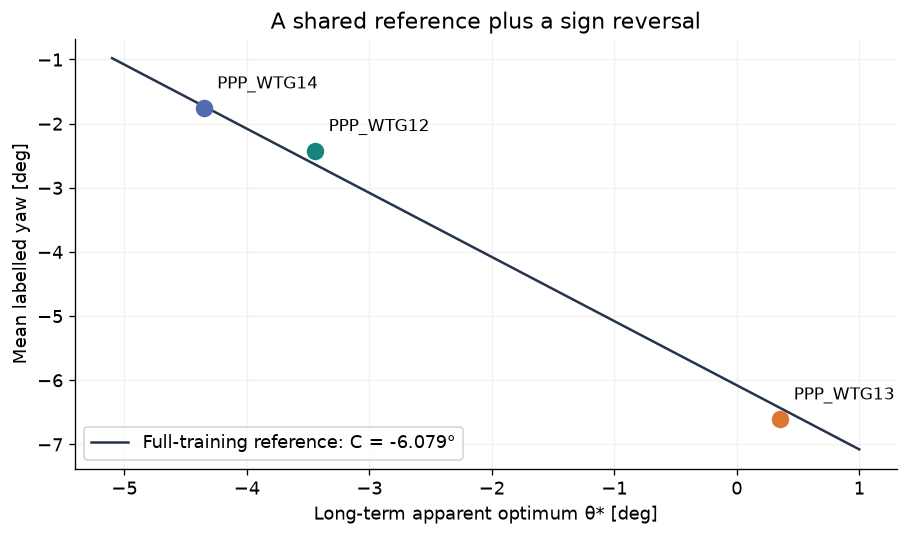

In [4]:
display(summary)
fig, ax = plt.subplots(figsize=(7.8, 4.6))
x = np.linspace(-5.1, 1.0, 100)
ax.plot(x, C_FINAL - x, color="#26344b", label=f"Full-training reference: C = {C_FINAL:.3f}°")
for (turbine, row), color in zip(summary.iterrows(), COLORS):
    ax.scatter(row.theta_star, row.target_mean, color=color, s=90, zorder=3)
    ax.annotate(turbine, (row.theta_star, row.target_mean), xytext=(8, 12),
                textcoords="offset points", fontsize=10)
ax.set(xlabel="Long-term apparent optimum θ* [deg]", ylabel="Mean labelled yaw [deg]",
       title="A shared reference plus a sign reversal")
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()
plt.close(fig)

## 5. Strict LOTO winner

For holdout $i$, compute $\hat C_{-i}$ from the other two turbines only, then predict a constant $\hat C_{-i}-\theta_i^\star$ for every date. The original sign check also chose between ±θ* using **only the two training-turbine means**, selecting −1 in all three outer folds. It did not run an explicit additional inner CV loop; the precise description is training-only sign selection within outer LOTO.

,selected_sign,C_hat,prediction,n_days,mae,rmse,bias
turbine_id,,,,,,,
PPP_WTG12,-1.000,-6.185,-2.744,725,0.354,0.601,-0.316
PPP_WTG13,-1.000,-5.991,-6.348,727,0.997,1.374,0.265
PPP_WTG14,-1.000,-6.062,-1.711,727,0.207,0.263,0.051


Strict LOTO macro MAE: 0.519°


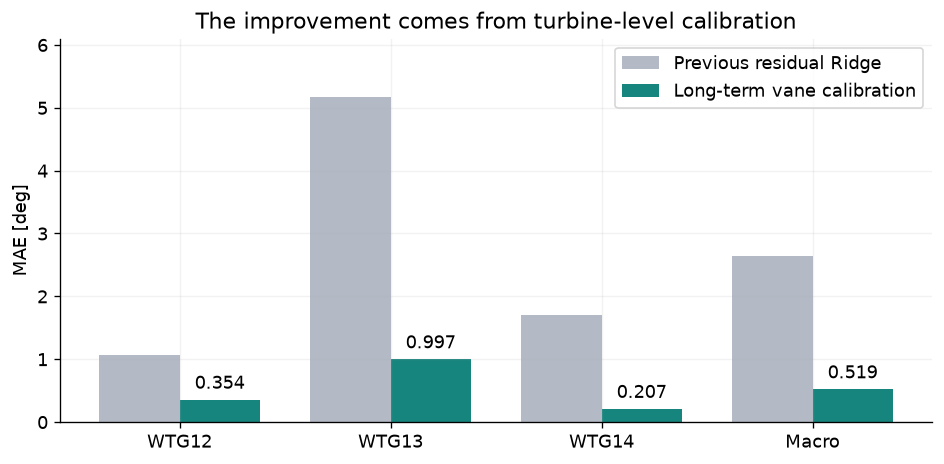

In [5]:
display(loto[["selected_sign", "C_hat", "prediction", "n_days", "mae", "rmse", "bias"]])
print(f"Strict LOTO macro MAE: {loto.mae.mean():.3f}°")
fig, ax = plt.subplots(figsize=(8, 4))
labels = [t.split("_")[1] for t in TRAIN] + ["Macro"]
winner = loto.mae.to_list() + [loto.mae.mean()]
prior = [1.063, 5.172, 1.704, 2.647]  # executed TrainValidation cell 7 / cell 20
positions = np.arange(len(labels))
ax.bar(positions - .19, prior, .38, label="Previous residual Ridge", color="#b3bac5")
bars = ax.bar(positions + .19, winner, .38, label="Long-term vane calibration", color=COLORS[0])
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(xticks=positions, xticklabels=labels, ylabel="MAE [deg]",
       title="The improvement comes from turbine-level calibration")
ax.set_ylim(0, 6.1)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

## 6. Why temporal dynamics were rejected

Daily apparent-optimum variation often persists while true labels form long plateaus. `TrainValidation` cells 13–14 report median absolute monthly target changes of **0° for all three turbines**, versus physics changes of 0.659° / 0.752° / 0.784°. The comparison below is an illustration from cached data, not a new fitted temporal model.

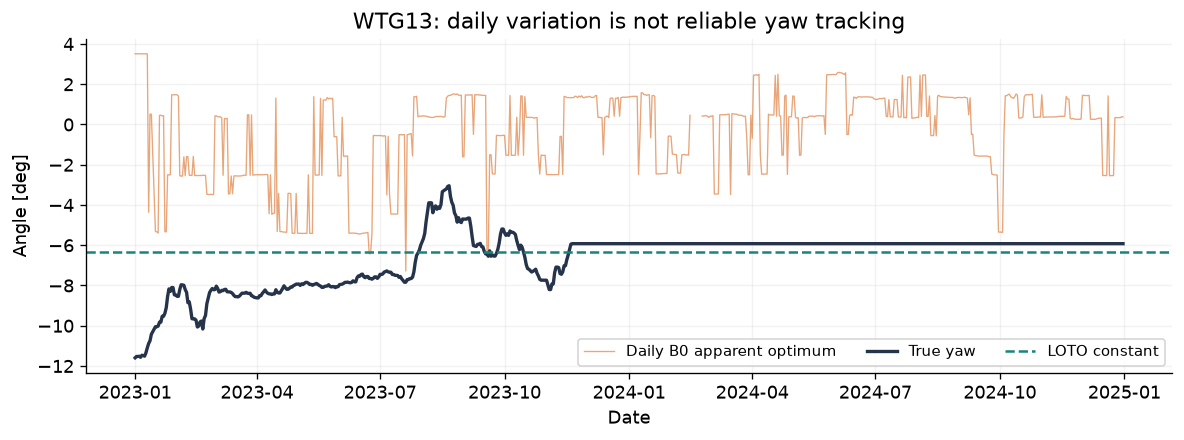

,method,macro_MAE_deg,source
0,Level only,0.519,Recomputed
1,Level + full centered physics dynamics,0.930,TrainValidation cell 20
2,Training-selected dynamics weight,0.580,TrainValidation cell 22


In [6]:
g = daily[daily.turbine_id.eq("PPP_WTG13")].sort_values("date")
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(g.date, g.theta_hat_argmax, color="#dc7633", alpha=.65, linewidth=.8, label="Daily B0 apparent optimum")
ax.plot(g.date, g.target, color="#26344b", linewidth=2, label="True yaw")
ax.axhline(loto.loc["PPP_WTG13", "prediction"], color=COLORS[0], linestyle="--", label="LOTO constant")
ax.set(title="WTG13: daily variation is not reliable yaw tracking", xlabel="Date", ylabel="Angle [deg]")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()
plt.close(fig)
display(pd.DataFrame({
    "method": ["Level only", "Level + full centered physics dynamics", "Training-selected dynamics weight"],
    "macro_MAE_deg": [loto.mae.mean(), .930, .580],
    "source": ["Recomputed", "TrainValidation cell 20", "TrainValidation cell 22"],
}))

## 7. Robustness

The constant oracle uses the **held-out turbine's own target median**, the MAE-optimal constant; it is not deployable. This differs from the earlier target-mean demeaning diagnostic.

We reproduce 500 shared-calendar 28-day block-bootstrap replicates (seed 42). Each replicate recomputes vane medians, calibration and LOTO MAE from cached daily windows. It **does not refit B0 on resampled raw SCADA**. The intervals measure temporal sampling robustness, not formal confidence or unseen-site error.

,quantity,MAE_deg
0,Strict LOTO point,0.519
1,Oracle constant,0.462
2,Bootstrap median,0.678
3,Bootstrap mean,0.738
4,Bootstrap 2.5 percentile,0.448
5,Bootstrap 97.5 percentile,1.470


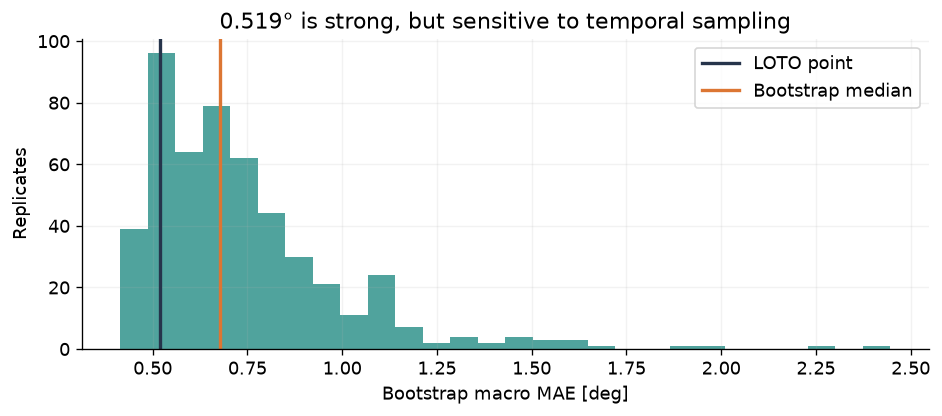

In [7]:
boot = bootstrap_loto(daily)
macro_boot = boot.groupby("replicate").mae.mean()
robustness = pd.DataFrame({
    "quantity": ["Strict LOTO point", "Oracle constant", "Bootstrap median", "Bootstrap mean",
                 "Bootstrap 2.5 percentile", "Bootstrap 97.5 percentile"],
    "MAE_deg": [loto.mae.mean(), loto.oracle_mae.mean(), macro_boot.median(), macro_boot.mean(),
                macro_boot.quantile(.025), macro_boot.quantile(.975)],
})
display(robustness)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(macro_boot, bins=28, color=COLORS[0], alpha=.75)
ax.axvline(loto.mae.mean(), color="#26344b", linewidth=2, label="LOTO point")
ax.axvline(macro_boot.median(), color="#dc7633", linewidth=2, label="Bootstrap median")
ax.set(title="0.519° is strong, but sensitive to temporal sampling",
       xlabel="Bootstrap macro MAE [deg]", ylabel="Replicates")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

## 8. Domain shift

Layout-only directional exposure is a **risk diagnostic**, not a calibrated wake model and not a term in the final equation. Recorded `TrainValidation` cells 39–41:

| Turbine | Mean directional exposure | Correlation with WTG12 exposure profile |
|---|---:|---:|
| PPP_WTG12 | 0.274 | 1.000 |
| PPP_WTG13 | 0.332 | — |
| PPP_WTG14 | 0.280 | — |
| PPP_WTG17 | 0.382 | 0.674 |
| SSS_WTG06 | 0.529 | −0.217 |

PPP_WTG17 has moderate layout shift and appreciable overlap with train profiles. SSS_WTG06 is a larger cross-site extrapolation; its profile correlations with all three PPP train turbines are negative (−0.217 / −0.174 / −0.180).

**Geometry matters physically, but no geometry-based correction improved strict validation.** Geometry-matched calibration worsened every fold: 0.519° → 0.533°.

SSS_WTG06 θ* = −1.511° is close to SSS_WTG05 = −1.553°. Its difference from the SSS context median is −1.896°, with a bootstrap robustness interval [−3.869°, 0.544°], so it is not a clearly established site-relative outlier. The raw PPP→SSS context shift of +1.910° is **not** used for yaw calibration.

## 9. Rejected alternatives

| Alternative | Validation evidence | Reason retained only as history |
|---|---|---|
| B1 / B2a | No improvement over B0 on appropriate comparisons | More fitting did not identify a better optimum |
| GP / paper-inspired route | No validated improvement | Abandoned for limited hackathon return |
| RF direct blend | 2.674° at 25% RF vs 2.647° residual Ridge | No gain |
| Enhanced residual | 2.642° vs 2.647° | 0.005° is not meaningful here |
| TV / dynamic tracking | 2.826° vs 2.829° physics; level dynamics 0.930° | False variation and negligible gain |
| Geometry-matched reference | 0.533° vs 0.519° | All folds worsened |
| Context-normalized reference | 2.142° vs 0.519° | Strong degradation |
| Generic ML power surface | 8.363° | Tree-surface plateaus/boundaries gave unstable argmax |

**Predicting power accurately is not the same as identifying the power-optimal yaw angle.** These findings do not establish that every possible ML or physical method must fail.

## 10. Frozen model and final predictions

$$\hat y=C_{FINAL}-\theta^\star,\qquad C_{FINAL}=-6.0793162066^\circ\;(\text{displayed as }-6.079^\circ).$$

Full-data predictions are frozen. Submission files export **−3.596000°** and **−4.568000°**, preserving the explicitly chosen three-decimal point values. Bootstrap means or medians never replace them.

The 1,000 target replicates use 28-day target blocks and independently sampled training-turbine blocks, reproducing original cell 51. Robustness intervals are **not formal confidence intervals**.

,theta_star,yaw_full_precision,frozen_export,n_valid,bootstrap_mean,bootstrap_std,robustness_lo,robustness_hi
turbine_id,,,,,,,,
PPP_WTG17,-2.484,-3.596,-3.596,651,-3.578,0.375,-4.527,-2.996
SSS_WTG06,-1.511,-4.568,-4.568,720,-4.438,1.365,-6.644,-2.280


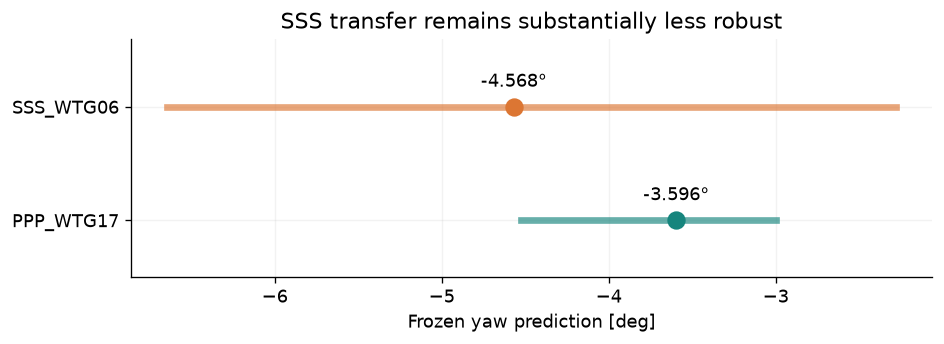

In [8]:
target_boot = bootstrap_targets(daily)
intervals = target_boot.groupby("turbine_id").yaw_hat.agg(
    bootstrap_mean="mean", bootstrap_std="std",
    robustness_lo=lambda x: x.quantile(.025), robustness_hi=lambda x: x.quantile(.975))
final = points.join(intervals)
display(final[["theta_star", "yaw_full_precision", "frozen_export", "n_valid",
               "bootstrap_mean", "bootstrap_std", "robustness_lo", "robustness_hi"]])
fig, ax = plt.subplots(figsize=(8, 3))
for i, turbine in enumerate(TARGETS):
    r = final.loc[turbine]
    ax.plot([r.robustness_lo, r.robustness_hi], [i, i], color=COLORS[i], linewidth=4, alpha=.65)
    ax.scatter(r.frozen_export, i, color=COLORS[i], s=100, zorder=3)
    ax.annotate(f"{r.frozen_export:.3f}°", (r.frozen_export, i), xytext=(0, 12),
                textcoords="offset points", ha="center")
ax.set(yticks=[0, 1], yticklabels=TARGETS, xlabel="Frozen yaw prediction [deg]",
       title="SSS transfer remains substantially less robust", ylim=(-.5, 1.6))
fig.tight_layout()
plt.show()
plt.close(fig)

## 11. Final interpretation and next step

The long-term apparent power-optimal vane position appears to compress turbine-specific aerodynamic/reference behavior into one scalar. On the three labelled turbines, the shared negative-sign calibration is the strongest validated candidate.

There is no validated evidence in these experiments that geometry corrections, context normalization, daily dynamics, residual ML or a generic ML power surface improve this final mapping. The main unresolved uncertainty is **transfer to a new site**, especially SSS. A new labelled site is more informative than another round of tuning on these three turbines.

**Frozen:** yaw = C − θ*. **LOTO macro MAE: 0.519°.** **PPP_WTG17: −3.596°. SSS_WTG06: −4.568°.**

### Evidence and reproduction

- Primary history: `experiments/power_vane/TrainValidation.ipynb` in the original workspace (cells 20/24/26/32/39–51).
- This release includes one small derived `data/vane_daily.csv`, not raw SCADA. The technical summary records source paths and checksums.
- Run `python -m unittest discover -s tests` and `python src/make_final_submission_vane_level.py` from the release directory.
- Optional raw-SCADA verification: `python src/make_final_submission_vane_level.py --verify-scada /path/to/turbines_data.zip`.
- Historical scores in sections 3/9 are explicitly recorded evidence, not newly rerun experiments.